# Email Spam Detection

- Misty Jangid (202401100500106)
- Milind Pushp (202401100500105)

This notebook builds and evaluates **multiple machine-learning classifiers** to distinguish spam e-mail from legitimate (ham) e-mail using the classic **Spambase dataset** from the UCI Machine Learning Repository.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

## Load Data

The Spambase dataset has **no header row**. We assign meaningful column names based on the UCI documentation.

In [ ]:
# ── Feature names from UCI documentation ─────────────────────────────────────
WORD_FREQ_FEATURES = [
    "word_freq_make", "word_freq_address", "word_freq_all", "word_freq_3d",
    "word_freq_our", "word_freq_over", "word_freq_remove", "word_freq_internet",
    "word_freq_order", "word_freq_mail", "word_freq_receive", "word_freq_will",
    "word_freq_people", "word_freq_report", "word_freq_addresses",
    "word_freq_free", "word_freq_business", "word_freq_email", "word_freq_you",
    "word_freq_credit", "word_freq_your", "word_freq_font", "word_freq_000",
    "word_freq_money", "word_freq_hp", "word_freq_hpl", "word_freq_george",
    "word_freq_650", "word_freq_lab", "word_freq_labs", "word_freq_telnet",
    "word_freq_857", "word_freq_data", "word_freq_415", "word_freq_85",
    "word_freq_technology", "word_freq_1999", "word_freq_parts",
    "word_freq_pm", "word_freq_direct", "word_freq_cs", "word_freq_meeting",
    "word_freq_original", "word_freq_project", "word_freq_re", "word_freq_edu",
    "word_freq_table", "word_freq_conference",
]

CHAR_FREQ_FEATURES = [
    "char_freq_semicolon", "char_freq_paren", "char_freq_bracket",
    "char_freq_exclaim", "char_freq_dollar", "char_freq_hash",
]

CAPITAL_FEATURES = [
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total",
]

COLUMN_NAMES = WORD_FREQ_FEATURES + CHAR_FREQ_FEATURES + CAPITAL_FEATURES + ["label"]

df = pd.read_csv("data/spambase.data", header=None, names=COLUMN_NAMES)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_paren,char_freq_bracket,char_freq_exclaim,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,label
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## Exploratory Data Analysis (EDA)

### Dataset Info & Missing Values

In [3]:
print(f"Shape : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows  : {df.duplicated().sum()}")
df.info()

Shape : (4601, 58)
Missing values : 0
Duplicate rows  : 391
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            46

### Class Distribution

label
Ham (0)     2788
Spam (1)    1813
Name: count, dtype: int64


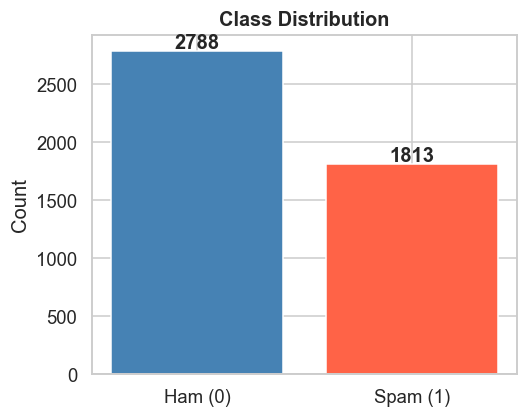

In [4]:
counts = df["label"].value_counts()
print(counts.rename({0: "Ham (0)", 1: "Spam (1)"}))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Ham (0)", "Spam (1)"], counts.values, color=["steelblue", "tomato"], edgecolor="white")
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha="center", fontweight="bold")
ax.set_title("Class Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Top Spam-Indicative Word Frequencies

We compare the **mean frequency** of each word feature between spam and ham emails to find the most differentiating words.

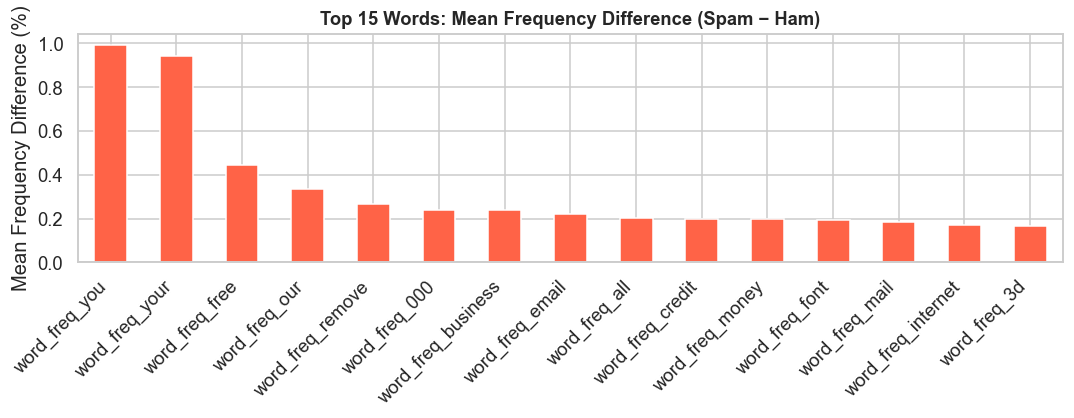

In [5]:
spam_means = df[df["label"] == 1][WORD_FREQ_FEATURES].mean()
ham_means  = df[df["label"] == 0][WORD_FREQ_FEATURES].mean()
diff = (spam_means - ham_means).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 4))
diff.plot(kind="bar", ax=ax, color="tomato", edgecolor="white")
ax.set_title("Top 15 Words: Mean Frequency Difference (Spam − Ham)", fontsize=12, fontweight="bold")
ax.set_ylabel("Mean Frequency Difference (%)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Data Preprocessing

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows. Remaining: {len(df)}")

df = df.fillna(df.median(numeric_only=True))

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Removed 391 duplicate rows. Remaining: 4210
Train size: 3368  |  Test size: 842


## Model Training & Comparison

We train **six classifiers** and compare their accuracy, precision, recall, F1-score, and ROC-AUC.

In [7]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

MODELS = {
    "Logistic Regression" : LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "SVM (Linear)"        : SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
    "SVM (RBF)"           : SVC(kernel="rbf",    probability=True, random_state=RANDOM_STATE),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "KNN (k=5)"           : KNeighborsClassifier(n_neighbors=5),
    "Naïve Bayes"         : GaussianNB(),
}

records = []

for name, model in MODELS.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    records.append({
        "Model"    : name,
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": report["weighted avg"]["precision"],
        "Recall"   : report["weighted avg"]["recall"],
        "F1-Score" : report["weighted avg"]["f1-score"],
        "ROC-AUC"  : roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(records).set_index("Model").sort_values("Accuracy", ascending=False)
results_df = results_df.map(lambda x: f"{x*100:.2f}%")
print(results_df.to_string())

                    Accuracy Precision  Recall F1-Score ROC-AUC
Model                                                          
Random Forest         94.42%    94.41%  94.42%   94.41%  98.98%
SVM (Linear)          93.59%    93.58%  93.59%   93.58%  97.67%
Logistic Regression   93.47%    93.46%  93.47%   93.45%  97.68%
SVM (RBF)             93.23%    93.23%  93.23%   93.21%  97.72%
KNN (k=5)             91.33%    91.34%  91.33%   91.28%  95.46%
Naïve Bayes           82.90%    86.16%  82.90%   83.06%  94.71%


### Accuracy Bar Chart

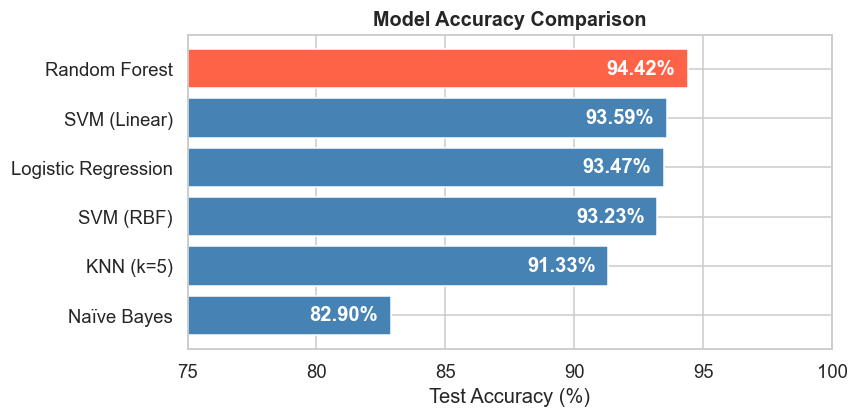

In [8]:
# Re-compute numeric results for plotting
numeric_records = []
for name, model in MODELS.items():
    y_pred = model.predict(X_test_sc)
    numeric_records.append({"Model": name, "Accuracy": accuracy_score(y_test, y_pred)})

nr_df = pd.DataFrame(numeric_records).sort_values("Accuracy", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))

colors = ["tomato" if v == nr_df["Accuracy"].max() else "steelblue" for v in nr_df["Accuracy"]]

bars = ax.barh(nr_df["Model"], nr_df["Accuracy"] * 100, color=colors, edgecolor="white")

for bar, val in zip(bars, nr_df["Accuracy"] * 100):
    ax.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}%", va="center", ha="right", color="white", fontweight="bold")

ax.set_xlim(75, 100)
ax.set_xlabel("Test Accuracy (%)")
ax.set_title("Model Accuracy Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Best Model Evaluation

We select the model with the **highest accuracy** for an in-depth evaluation.

In [9]:
best_name   = nr_df.iloc[-1]["Model"]
best_model  = MODELS[best_name]
y_pred_best = best_model.predict(X_test_sc)
y_prob_best = best_model.predict_proba(X_test_sc)[:, 1]

print(f"  Best Model : {best_name}")
print(f"   Accuracy  : {accuracy_score(y_test, y_pred_best)*100:.2f}%")
print(f"   ROC-AUC   : {roc_auc_score(y_test, y_prob_best):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=["Ham (0)", "Spam (1)"]))

  Best Model : Random Forest
   Accuracy  : 94.42%
   ROC-AUC   : 0.9898

Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.95      0.96      0.95       506
    Spam (1)       0.94      0.92      0.93       336

    accuracy                           0.94       842
   macro avg       0.94      0.94      0.94       842
weighted avg       0.94      0.94      0.94       842



### Confusion Matrix

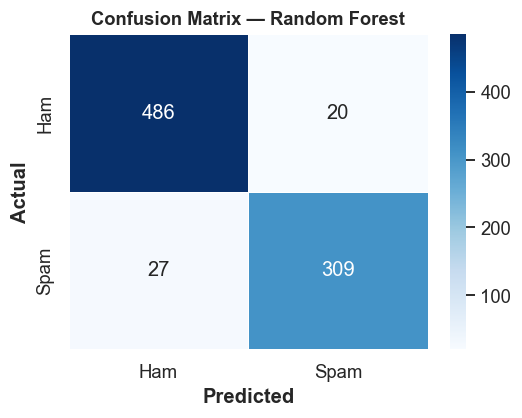

In [10]:
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"],
    linewidths=0.5, ax=ax
)
ax.set_ylabel("Actual", fontweight="bold")
ax.set_xlabel("Predicted", fontweight="bold")
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### ROC Curve

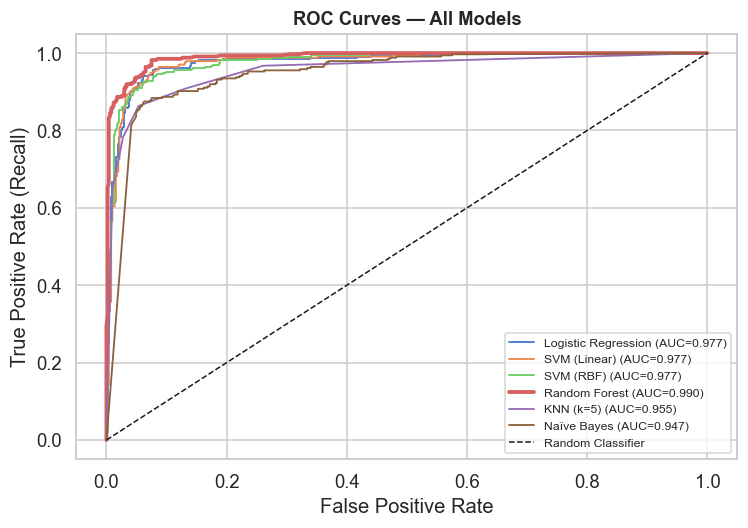

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, model in MODELS.items():
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    lw = 2.5 if name == best_name else 1.2
    ax.plot(fpr, tpr, lw=lw, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curves — All Models", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)

If the best model is a Random Forest we can inspect **which features drive predictions most**.

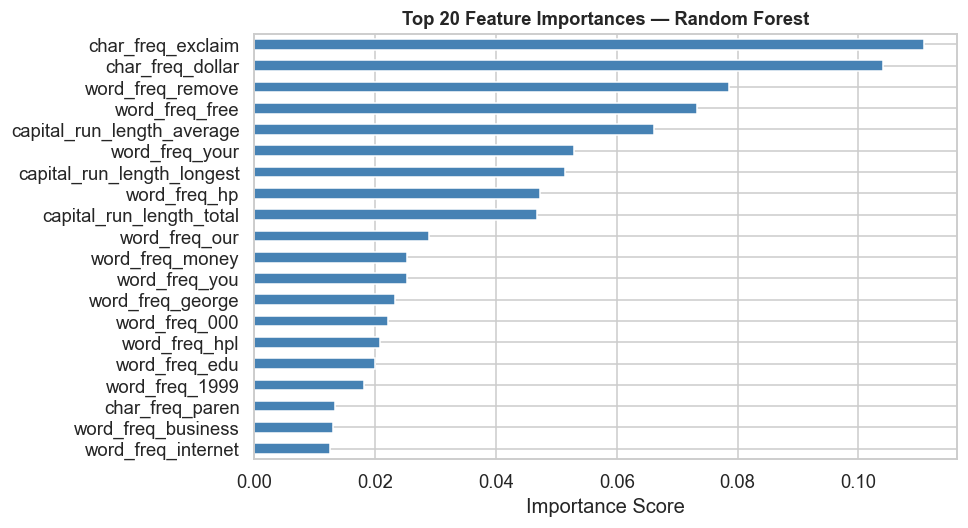

In [12]:
rf_model = MODELS["Random Forest"]
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
top20 = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 5))
top20.sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 20 Feature Importances — Random Forest", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

### Actual vs. Predicted (First 50 Test Samples)

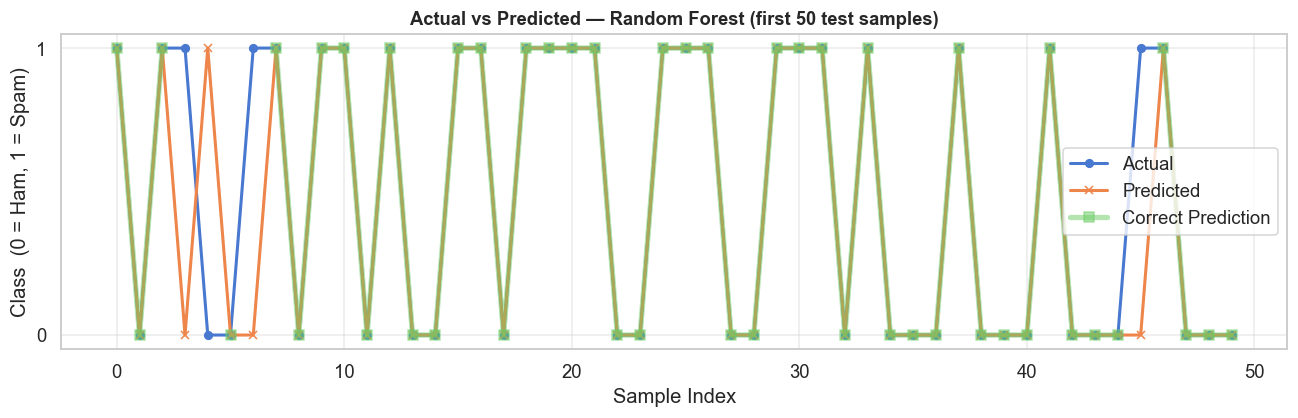

In [13]:
actual  = y_test.values[:50]
pred    = y_pred_best[:50]
overlap = np.where(actual == pred, actual, np.nan)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(actual,  lw=2,   marker="o", label="Actual",          markersize=5)
ax.plot(pred,    lw=2,   marker="x", label="Predicted",        markersize=5)
ax.plot(overlap, lw=3.5, marker="s", label="Correct Prediction", alpha=0.5, markersize=6)

ax.set_title(f"Actual vs Predicted — {best_name} (first 50 test samples)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Class  (0 = Ham, 1 = Spam)")
ax.set_yticks([0, 1])
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()